# Solver-Aware Drip-Irrigation Wetting Bulb Model
### Gregory Guevara

**Zenodo reproducibility release — September 2026**


This notebook contains the archived axisymmetric Richards-equation solver, texture-specific numerical configurations, wetting-bulb calculator, and numerical verification checks used in the associated manuscript.


In [1]:
# ==========================================================
# BLOCK 0: COMPLETE NOTEBOOK BASE
# Axisymmetric Richards + Picard + snapshots + cache-ready workflow
# ==========================================================

import os
import time
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.sparse.linalg import spsolve

# ----------------------------------------------------------
# 0.1 GENERAL CONFIGURATION
# ----------------------------------------------------------
OUTDIR = "richards_axisymmetric_sensitivity_v1"
SAVE_DIR = os.path.join(OUTDIR, "saved_results")
FIGDIR = os.path.join(OUTDIR, "figures")
NPZ_DIR = os.path.join(SAVE_DIR, "npz_runs")

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(NPZ_DIR, exist_ok=True)

RESULTS_SUMMARY_CSV = os.path.join(SAVE_DIR, "results_summary.csv")
RUNLOG_CSV = os.path.join(SAVE_DIR, "run_log.csv")

FORCE_RERUN = False

# Zenodo/review traceability
SOLVER_VERSION = "Zenodo_reproducibility_release_2026_09"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.titlesize": 16,
    "axes.linewidth": 1.0,
    "savefig.dpi": 400,
    "savefig.bbox": "tight"
})

# ----------------------------------------------------------
# 0.2 SOIL PARAMETERS
# Edit only if the final reference parameter set changes
# ----------------------------------------------------------
soil_params = {
    "Loamy Sand": {
        "texture": "Loamy Sand",
        "theta_r": 0.057,
        "theta_s": 0.410,
        "alpha": 0.124,
        "n": 2.28,
        "Ks": 14.59,   # cm/h
    },
    "Loam": {
        "texture": "Loam",
        "theta_r": 0.078,
        "theta_s": 0.430,
        "alpha": 0.036,
        "n": 1.56,
        "Ks": 1.04,    # cm/h
    },
    "Clay Loam": {
        "texture": "Clay Loam",
        "theta_r": 0.095,
        "theta_s": 0.410,
        "alpha": 0.019,
        "n": 1.31,
        "Ks": 0.26,    # cm/h
    }
}

pd.DataFrame(soil_params).T.reset_index(drop=True).to_csv(
    os.path.join(SAVE_DIR, "soil_params_base.csv"), index=False
)

# ----------------------------------------------------------
# 0.3 AXISYMMETRIC DOMAIN
# ----------------------------------------------------------
Rmax = 50.0   # cm
Zmax = 50.0   # cm
dr = 1.0      # cm
dz = 1.0      # cm

nr = int(Rmax / dr)
nz = int(Zmax / dz)
N = nr * nz

r = (np.arange(nr) + 0.5) * dr
z = (np.arange(nz) + 0.5) * dz  # computational depth coordinate, positive downward

print(f"Axisymmetric domain: Rmax={Rmax} cm, Zmax={Zmax} cm")
print(f"Grid: nr={nr}, nz={nz}, N={N}")

# ----------------------------------------------------------
# 0.4 PRECOMPUTED GEOMETRY
# ----------------------------------------------------------
def cell_edges_from_centers(r, dr):
    r_inner = np.maximum(r - 0.5 * dr, 0.0)
    r_outer = r + 0.5 * dr
    return r_inner, r_outer

r_inner, r_outer = cell_edges_from_centers(r, dr)

rw_arr = np.maximum(r - 0.5 * dr, 0.0)
re_arr = r + 0.5 * dr
A_h_arr = 2.0 * np.pi * r * dr
V_arr = 2.0 * np.pi * r * dr * dz
A_rw_arr = 2.0 * np.pi * rw_arr * dz
A_re_arr = 2.0 * np.pi * re_arr * dz

cell_volume = np.tile(V_arr, (nz, 1))

# ----------------------------------------------------------
# 0.5 AUXILIARY FUNCTIONS
# ----------------------------------------------------------
def idx(i, j):
    return i * nr + j

def harmonic_mean(a, b, eps=1e-30):
    return 2.0 * a * b / (a + b + eps)

def mirror_field(r, field2d):
    r_plot = np.concatenate((-r[::-1], r))
    field_plot = np.hstack((field2d[:, ::-1], field2d))
    return r_plot, field_plot

def stable_hash(obj):
    txt = json.dumps(obj, sort_keys=True, default=str)
    return hashlib.md5(txt.encode("utf-8")).hexdigest()[:16]

def ensure_results_files():
    if not os.path.exists(RESULTS_SUMMARY_CSV):
        pd.DataFrame().to_csv(RESULTS_SUMMARY_CSV, index=False)
    if not os.path.exists(RUNLOG_CSV):
        pd.DataFrame(columns=["case_id", "status", "message"]).to_csv(RUNLOG_CSV, index=False)

def append_runlog(case_id, status, message):
    ensure_results_files()
    df = pd.read_csv(RUNLOG_CSV)
    df = pd.concat([df, pd.DataFrame([{
        "case_id": case_id,
        "status": status,
        "message": message
    }])], ignore_index=True)
    df.to_csv(RUNLOG_CSV, index=False)

# ----------------------------------------------------------
# 0.6 VAN GENUCHTEN-MUALEM HYDRAULIC FUNCTIONS
# ----------------------------------------------------------
def hydraulic_functions(soil):
    theta_r = soil["theta_r"]
    theta_s = soil["theta_s"]
    alpha = soil["alpha"]
    n = soil["n"]
    Ks = soil["Ks"]
    m = 1.0 - 1.0 / n

    def theta(h):
        h = np.asarray(h, dtype=float)
        hneg = np.minimum(h, 0.0)
        Se = (1.0 + (alpha * np.abs(hneg))**n)**(-m)
        th = theta_r + (theta_s - theta_r) * Se
        th = np.where(h >= 0.0, theta_s, th)
        return th

    def C(h):
        h = np.asarray(h, dtype=float)
        hneg = np.minimum(h, 0.0)
        ahn = alpha * np.abs(hneg)

        out = np.zeros_like(hneg, dtype=float)
        mask = hneg < 0.0
        if np.any(mask):
            num = (theta_s - theta_r) * m * alpha * n * (ahn[mask] ** (n - 1.0))  # corrected dtheta/dh
            den = (1.0 + ahn[mask] ** n) ** (m + 1.0)
            out[mask] = num / den

        return np.maximum(out, 1e-10)

    def K(h):
        h = np.asarray(h, dtype=float)
        th = theta(h)
        Se = (th - theta_r) / max(theta_s - theta_r, 1e-12)
        Se = np.clip(Se, 1e-12, 1.0)
        Kr = np.sqrt(Se) * (1.0 - (1.0 - Se ** (1.0 / m)) ** m) ** 2
        return Ks * Kr

    return theta, C, K

# ----------------------------------------------------------
# 0.7 EMITTER AND MATRIX ASSEMBLY
# ----------------------------------------------------------
def build_emitter_geometry(Q_Lh, emitter_radius):
    Q_cm3h = Q_Lh * 1000.0

    emitter_area_j = np.zeros(nr)
    for j in range(nr):
        overlap_in = r_inner[j]
        overlap_out = min(r_outer[j], emitter_radius)
        if overlap_out > overlap_in:
            emitter_area_j[j] = np.pi * (overlap_out**2 - overlap_in**2)

    A_emitter_discrete = emitter_area_j.sum()
    if A_emitter_discrete <= 0:
        raise ValueError("El emisor no intersecta ninguna celda en la frontera superior.")

    q_emit = Q_cm3h / A_emitter_discrete
    emitter_top_flux = np.where(emitter_area_j > 0, q_emit, 0.0)
    emitter_cells = np.where(emitter_area_j > 0)[0]

    return Q_cm3h, emitter_area_j, emitter_top_flux, emitter_cells

def assemble_picard_system(
    h_iter, theta_old, theta_fun, C_fun, K_fun, dt,
    emitter_area_j, emitter_top_flux
):
    theta_iter = theta_fun(h_iter)
    C_iter = C_fun(h_iter)
    K_iter = K_fun(h_iter)

    rows, cols, data = [], [], []
    rhs = np.zeros(N)

    for i in range(nz):
        for j in range(nr):
            k = idx(i, j)

            V = V_arr[j]
            A_h = A_h_arr[j]

            diag = C_iter[k] * V / dt
            b = (theta_old[k] - theta_iter[k] + C_iter[k] * h_iter[k]) * V / dt

            # radial west
            if j > 0:
                kw = idx(i, j - 1)
                Kint = harmonic_mean(K_iter[k], K_iter[kw])
                cond = Kint * A_rw_arr[j] / dr
                rows.append(k); cols.append(kw); data.append(-cond)
                diag += cond

            # radial east
            if j < nr - 1:
                ke = idx(i, j + 1)
                Kint = harmonic_mean(K_iter[k], K_iter[ke])
                cond = Kint * A_re_arr[j] / dr
                rows.append(k); cols.append(ke); data.append(-cond)
                diag += cond

            # upper
            if i > 0:
                ku = idx(i - 1, j)
                Kint = harmonic_mean(K_iter[k], K_iter[ku])
                cond = Kint * A_h / dz
                rows.append(k); cols.append(ku); data.append(-cond)
                diag += cond
                b += Kint * A_h  # gravity: upper-face contribution for depth-positive-downward coordinate
            else:
                if emitter_area_j[j] > 0:
                    b += emitter_top_flux[j] * emitter_area_j[j]

            # lower
            if i < nz - 1:
                kd = idx(i + 1, j)
                Kint = harmonic_mean(K_iter[k], K_iter[kd])
                cond = Kint * A_h / dz
                rows.append(k); cols.append(kd); data.append(-cond)
                diag += cond
                b -= Kint * A_h  # gravity: lower-face contribution for depth-positive-downward coordinate
            else:
                b -= K_iter[k] * A_h

            rows.append(k); cols.append(k); data.append(diag)
            rhs[k] = b

    A = sparse.csr_matrix((data, (rows, cols)), shape=(N, N))
    return A, rhs

# ----------------------------------------------------------
# 0.8 AXISYMMETRIC PICARD SOLVER
# ----------------------------------------------------------
def run_simulation_picard_axisymmetric(
    soil,
    Q_Lh,
    emitter_radius,
    dt_list,
    nt,
    t_final,
    h_init_common=-75.0,
    max_iter=60,
    tol=5e-4,
    omega_default=0.30,
    omega_min=0.08,
    omega_max=0.50,
    max_dh_default=18.0,
    rescue_iter=90,
    solver_settings=None,
    snapshot_times_h=None,
    verbose=True
):
    if solver_settings is None:
        solver_settings = {
            "rescue_omega_scale": 0.60,
            "rescue_max_dh_scale": 0.60,
            "rescue_max_dh_floor": 10.0,
            "err_worsen_factor": 1.02,
            "worsen_omega_scale": 0.70,
            "worsen_max_dh_scale": 0.80,
            "worsen_max_dh_floor": 8.0,
            "err_improve_factor": 0.50,
            "improve_omega_scale": 1.03,
        }

    theta_fun, C_fun, K_fun = hydraulic_functions(soil)
    Q_cm3h, emitter_area_j, emitter_top_flux, emitter_cells = build_emitter_geometry(Q_Lh, emitter_radius)

    h_old = np.full(N, h_init_common, dtype=float)
    iter_history = []
    omega_history = []
    rescued_steps = 0
    nonconv_steps = 0

    snapshots = {}
    snapshot_times_h = [] if snapshot_times_h is None else list(snapshot_times_h)
    next_snapshot_idx = 0
    snapshot_times_h = sorted(snapshot_times_h)

    t_now = 0.0
    t0 = time.time()

    for istep, dt in enumerate(dt_list, start=1):
        h_iter = h_old.copy()
        theta_old = theta_fun(h_old)

        converged = False
        step_used_rescue = False

        for attempt in range(2):
            if attempt == 0:
                omega = omega_default
                max_dh = max_dh_default
                step_max_iter = max_iter
            else:
                omega = max(omega_default * solver_settings["rescue_omega_scale"], omega_min)
                max_dh = max(max_dh_default * solver_settings["rescue_max_dh_scale"], solver_settings["rescue_max_dh_floor"])
                step_max_iter = rescue_iter
                step_used_rescue = True

            h_try = h_iter.copy()
            prev_err = None

            for it in range(step_max_iter):
                A, rhs = assemble_picard_system(
                    h_try, theta_old, theta_fun, C_fun, K_fun, dt,
                    emitter_area_j, emitter_top_flux
                )
                h_sol = spsolve(A, rhs)

                dh = np.clip(h_sol - h_try, -max_dh, max_dh)
                # Existing model assumption retained for reproducibility: h is capped at 0 cm
                # (unsaturated/atmospheric-pressure limit; no positive-pressure ponding state).
                h_new = np.minimum(h_try + omega * dh, 0.0)

                err = np.max(np.abs(h_new - h_try))

                if prev_err is not None and err > prev_err * solver_settings["err_worsen_factor"]:
                    omega = max(omega * solver_settings["worsen_omega_scale"], omega_min)
                    max_dh = max(max_dh * solver_settings["worsen_max_dh_scale"], solver_settings["worsen_max_dh_floor"])
                elif prev_err is not None and err < prev_err * solver_settings["err_improve_factor"]:
                    omega = min(omega * solver_settings["improve_omega_scale"], omega_max)

                h_try = h_new
                prev_err = err

                if err < tol:
                    converged = True
                    h_iter = h_try.copy()
                    iter_history.append(it + 1)
                    omega_history.append(float(omega))
                    if step_used_rescue:
                        rescued_steps += 1
                    break

            if converged:
                break

        if not converged:
            # Existing screening logic retained for reproducibility: the final relaxed iterate
            # is carried forward and the step is counted in nonconv_steps.
            nonconv_steps += 1
            h_iter = h_try.copy()
            iter_history.append(step_max_iter)
            omega_history.append(float(omega))

        h_old = h_iter.copy()
        t_now += dt

        while next_snapshot_idx < len(snapshot_times_h) and t_now >= snapshot_times_h[next_snapshot_idx] - 1e-12:
            theta2d_snap = theta_fun(h_old).reshape((nz, nr))
            h2d_snap = h_old.reshape((nz, nr))
            theta_init_snap = theta_fun(np.full_like(h_old, h_init_common)).reshape((nz, nr))
            snapshots[float(snapshot_times_h[next_snapshot_idx])] = {
                "theta2d": theta2d_snap.copy(),
                "h2d": h2d_snap.copy(),
                "theta_init": theta_init_snap.copy()
            }
            next_snapshot_idx += 1

        if verbose and (istep == 1 or istep % 20 == 0 or istep == nt):
            elapsed = time.time() - t0
            print(
                f"    step {istep:>4}/{nt} | dt={dt:.4f} h | "
                f"elapsed={elapsed:.1f}s | nonconv={nonconv_steps}"
            )

    h2d = h_old.reshape((nz, nr))
    theta2d = theta_fun(h_old).reshape((nz, nr))
    theta_init = theta_fun(np.full_like(h_old, h_init_common)).reshape((nz, nr))

    total_applied = Q_cm3h * t_final
    storage_gain = np.sum((theta2d - theta_init) * cell_volume)
    storage_ratio = storage_gain / total_applied if total_applied > 0 else np.nan
    nonconv_ratio = nonconv_steps / nt if nt > 0 else np.nan

    return {
        "h2d": h2d,
        "theta2d": theta2d,
        "theta_init": theta_init,
        "h_init": h_init_common,
        "iter_history": np.array(iter_history, dtype=int),
        "omega_history": np.array(omega_history, dtype=float),
        "rescued_steps": rescued_steps,
        "nonconv_steps": nonconv_steps,
        "nonconv_ratio": nonconv_ratio,
        "storage_gain": storage_gain,
        "storage_ratio": storage_ratio,
        "Q_cm3h": Q_cm3h,
        "reliable": nonconv_ratio <= 0.10,
        "snapshots": snapshots
    }

print("Block 0 loaded successfully.")

Axisymmetric domain: Rmax=50.0 cm, Zmax=50.0 cm
Grid: nr=50, nz=50, N=2500
Block 0 loaded successfully.


In [2]:
# ==========================================================
# BLOCK 1: FROZEN PROJECT CONFIGURATION
# ==========================================================

RUN_ID = "Axisymmetric_Richards_Sensitivity_FinalProject_v1"
RUN_NOTE = (
    "Sensitivity notebook built on the frozen axisymmetric Richards-Picard architecture. "
    "Mathematical calibration is frozen by texture; physical sensitivity is evaluated separately."
)

# ----------------------------------------------------------
# 1.1 FINAL FROZEN NUMERICAL CONFIGURATION
# ----------------------------------------------------------
FROZEN_NUMERICAL_CONFIGS = {
    "Loamy Sand": {
        "phase_run_id": "C2_R2",
        "schedule_name": "coarse_ultra_transition",
        "variant_name": "coarse_A",
        "h_init_common": -50.0,
        "max_iter": 65,
        "rescue_iter": 95,
        "tol": 6e-4,
        "omega_default": 0.32,
        "omega_min": 0.08,
        "omega_max": 0.45,
        "max_dh_default": 16.0,
    },
    "Loam": {
        "phase_run_id": "M3_R1",
        "schedule_name": "medium_safe_track",
        "variant_name": "medium_A",
        "h_init_common": -60.0,
        "max_iter": 70,
        "rescue_iter": 95,
        "tol": 6e-4,
        "omega_default": 0.25,
        "omega_min": 0.08,
        "omega_max": 0.40,
        "max_dh_default": 14.0,
    },
    "Clay Loam": {
        "phase_run_id": "C5_R1",
        "schedule_name": "fine_careful_start",
        "variant_name": "candidate_A",
        "h_init_common": -75.0,
        "max_iter": 80,
        "rescue_iter": 110,
        "tol": 6e-4,
        "omega_default": 0.24,
        "omega_min": 0.06,
        "omega_max": 0.36,
        "max_dh_default": 13.0,
    }
}

# ----------------------------------------------------------
# 1.2 ADAPTIVE SOLVER VARIANTS
# candidate_A: if an exact earlier configuration is required,
# replace ONLY this dictionary
# ----------------------------------------------------------
SOLVER_VARIANTS_FROZEN = {
    "coarse_A": {
        "rescue_omega_scale": 0.60,
        "rescue_max_dh_scale": 0.60,
        "rescue_max_dh_floor": 8.0,
        "err_worsen_factor": 1.020,
        "worsen_omega_scale": 0.75,
        "worsen_max_dh_scale": 0.85,
        "worsen_max_dh_floor": 8.0,
        "err_improve_factor": 0.55,
        "improve_omega_scale": 1.02,
    },
    "medium_A": {
        "rescue_omega_scale": 0.60,
        "rescue_max_dh_scale": 0.60,
        "rescue_max_dh_floor": 8.0,
        "err_worsen_factor": 1.020,
        "worsen_omega_scale": 0.75,
        "worsen_max_dh_scale": 0.85,
        "worsen_max_dh_floor": 8.0,
        "err_improve_factor": 0.55,
        "improve_omega_scale": 1.02,
    },
    
    "candidate_A": {
        "rescue_omega_scale": 0.60,
        "rescue_max_dh_scale": 0.60,
        "rescue_max_dh_floor": 10.0,
        "err_worsen_factor": 1.02,
        "worsen_omega_scale": 0.70,
        "worsen_max_dh_scale": 0.80,
        "worsen_max_dh_floor": 8.0,
        "err_improve_factor": 0.50,
        "improve_omega_scale": 1.03,
    }
    
}

# ----------------------------------------------------------
# 1.3 TIME-STEP SCHEDULES
# fine_careful_start: replace here only if an exact archived sequence is required
# ----------------------------------------------------------
DT_SCHEDULES_PHYSICAL = {
    "coarse_ultra_transition": [
        (0.10, 0.001),
        (0.60, 0.002),
        (1.80, 0.003),
        (3.00, 0.006),
        (4.00, 0.012),
    ],
    "medium_safe_track": [
        (0.10, 0.001),
        (0.50, 0.002),
        (1.40, 0.004),
        (2.60, 0.008),
        (4.00, 0.012),
    ],
    "fine_careful_start": [
        (0.20, 0.001),
        (0.70, 0.002),
        (1.50, 0.003),
        (2.50, 0.005),
        (4.00, 0.010),
    ],

    # Alternative variants for numerical sensitivity analysis
    "coarse_guarded_alt": [
        (0.15, 0.0010),
        (0.80, 0.0015),
        (2.00, 0.0030),
        (3.20, 0.0050),
        (4.00, 0.0100),
    ],
    "medium_guarded_alt": [
        (0.15, 0.0010),
        (0.70, 0.0020),
        (1.80, 0.0030),
        (3.00, 0.0060),
        (4.00, 0.0100),
    ],
    "fine_guarded_alt": [
        (0.60, 0.0010),
        (1.40, 0.0015),
        (2.20, 0.0020),
        (3.20, 0.0025),
        (4.00, 0.0030),
    ],
}

SCHEDULE_SENSITIVITY_BY_TEXTURE = {
    "Loamy Sand": ["coarse_ultra_transition", "coarse_guarded_alt"],
    "Loam": ["medium_safe_track", "medium_guarded_alt"],
    "Clay Loam": ["fine_careful_start", "fine_guarded_alt"],
}

# ----------------------------------------------------------
# 1.4 TEXTURE-SPECIFIC PHYSICAL BASELINES
# Numerical controls are frozen first; physical baseline settings are defined separately.
# ----------------------------------------------------------
PHYSICAL_BASELINES = {
    "Loamy Sand": {
        "Q_Lh": 1.0,
        "emitter_radius_cm": 1.0,
        "fw_threshold": 0.50,
        "t_final_h": 3.0,
    },
    "Loam": {
        "Q_Lh": 1.0,
        "emitter_radius_cm": 1.5,
        "fw_threshold": 0.50,
        "t_final_h": 3.0,
    },
    "Clay Loam": {
        "Q_Lh": 1.0,
        "emitter_radius_cm": 1.75,
        "fw_threshold": 0.45,
        "t_final_h": 3.5,
    }
}

# ----------------------------------------------------------
# 1.5 COMMON PHYSICAL COMPARISON SCENARIO ACROSS TEXTURES
# Common comparison condition: 1.0 L/h and 4 h
# ----------------------------------------------------------
COMMON_COMPARISON = {
    "Q_Lh": 1.0,
    "t_final_h": 4.0
}

# ----------------------------------------------------------
# 1.6 DISCHARGE × TIME EXPERIMENT
# ----------------------------------------------------------
QT_TEXTURE = "Loam"
QT_Q_LEVELS = [0.5, 1.0, 2.0]
QT_SNAPSHOT_TIMES_H = [0.5, 1.0, 2.0, 4.0]

# ----------------------------------------------------------
# 1.7 NUMERICAL-CONTROL SENSITIVITY
# ----------------------------------------------------------
NUMERICAL_SENSITIVITY_VALUES = {
    "omega_default": [0.22, 0.24, 0.25, 0.28, 0.30, 0.32],
    "tol": [1e-3, 8e-4, 6e-4, 5e-4],
    "max_dh_default": [12.0, 13.0, 14.0, 16.0],
}

# ----------------------------------------------------------
# 1.8 PHYSICAL-PARAMETER SENSITIVITY
# ----------------------------------------------------------
PHYSICAL_SENSITIVITY_VALUES = {
    "Ks_rel": [-0.30, -0.20, -0.10, 0.10, 0.20, 0.30],
    "alpha_rel": [-0.30, -0.20, -0.10, 0.10, 0.20, 0.30],
    "n_rel": [-0.15, -0.10, -0.05, 0.05, 0.10, 0.15],
    "fw_threshold": [0.40, 0.45, 0.50, 0.55, 0.60],
    "emitter_radius_rel": [-0.30, -0.20, -0.10, 0.10, 0.20, 0.30],
}

# ----------------------------------------------------------
# 1.9 RANGO DE PLOTEO
# ----------------------------------------------------------
PLOT_RMAX = 50.0
PLOT_ZMAX = 50.0

TEXTURE_COLORS = {
    "Loamy Sand": "#1c3d73",
    "Loam": "#2f6f7e",
    "Clay Loam": "#8b5a2b"
}

print("Block 1 loaded successfully.")

Block 1 loaded successfully.


In [3]:
# ==========================================================
# BLOCK 2: METRICS, TIME GRID, AND GENERIC RUN FUNCTIONS
# ==========================================================

def build_time_grid_local(dt_schedule):
    times = [0.0]
    t = 0.0
    for t_end, dt in dt_schedule:
        while t < t_end - 1e-12:
            dt_use = min(dt, t_end - t)
            t += dt_use
            times.append(t)
    return np.array(times)

def build_dt_data_local(schedule_name, t_final_override=None):
    dt_schedule = DT_SCHEDULES_PHYSICAL[schedule_name]
    time_grid = build_time_grid_local(dt_schedule)

    if t_final_override is not None:
        time_grid = time_grid[time_grid <= t_final_override + 1e-12]
        if abs(time_grid[-1] - t_final_override) > 1e-12:
            time_grid = np.append(time_grid, t_final_override)

    dt_list = np.diff(time_grid)
    nt = len(dt_list)
    t_final = float(time_grid[-1])
    return dt_schedule, time_grid, dt_list, nt, t_final

def get_variant_settings_frozen(variant_name):
    return SOLVER_VARIANTS_FROZEN[variant_name].copy()

def compute_wetting_metrics_physical(theta2d, theta_init, soil, fw_threshold=0.50):
    theta_s = soil["theta_s"]

    wet_frac = (theta2d - theta_init) / (theta_s - theta_init + 1e-9)
    wet_frac = np.clip(wet_frac, 0.0, 1.0)
    wet_mask = wet_frac >= fw_threshold

    z_idx = np.where(np.any(wet_mask, axis=1))[0]
    r_idx = np.where(np.any(wet_mask, axis=0))[0]

    depth = z[z_idx.max()] if len(z_idx) > 0 else np.nan
    radial_extent = r[r_idx.max()] if len(r_idx) > 0 else np.nan
    width = 2.0 * radial_extent if np.isfinite(radial_extent) else np.nan
    volume = np.sum(cell_volume[wet_mask]) if np.any(wet_mask) else 0.0
    shape_ratio = depth / max(radial_extent, 1e-9) if np.isfinite(depth) and np.isfinite(radial_extent) else np.nan

    return {
        "depth": depth,
        "radial_extent": radial_extent,
        "width": width,
        "volume": volume,
        "shape_ratio": shape_ratio,
        "wet_frac": wet_frac,
        "wet_mask": wet_mask
    }

def classify_numerical_quality(nonconv_ratio, storage_ratio):
    if nonconv_ratio <= 0.15 and storage_ratio >= 0.95:
        return "High"
    elif nonconv_ratio <= 0.25 and storage_ratio >= 0.93:
        return "Moderate"
    elif nonconv_ratio <= 0.40 and storage_ratio >= 0.90:
        return "Low"
    return "Unreliable"

def build_case_id(case_dict):
    return stable_hash(case_dict)

def load_results_summary():
    ensure_results_files()
    try:
        df = pd.read_csv(RESULTS_SUMMARY_CSV)
        return df
    except Exception:
        return pd.DataFrame()

def append_results_row(row_dict):
    ensure_results_files()
    df = load_results_summary()
    if "case_id" in df.columns:
        df = df[df["case_id"] != row_dict["case_id"]]
    df = pd.concat([df, pd.DataFrame([row_dict])], ignore_index=True)
    df.to_csv(RESULTS_SUMMARY_CSV, index=False)

def save_case_npz(case_id, res):
    fname = os.path.join(NPZ_DIR, f"{case_id}.npz")
    payload = {
        "texture": res["texture"],
        "scenario_name": res["scenario_name"],
        "theta2d": res["theta2d"],
        "theta_init": res["theta_init"],
        "h2d": res["h2d"],
        "wet_frac": res["wet_frac"],
        "wet_mask": res["wet_mask"].astype(int),
        "r": r,
        "z": z
    }

    # optional snapshots
    if "snapshots" in res and res["snapshots"] is not None:
        payload["snapshot_times"] = np.array(sorted(res["snapshots"].keys()), dtype=float)
        for ts in sorted(res["snapshots"].keys()):
            tag = str(ts).replace(".", "_")
            payload[f"theta2d_t_{tag}"] = res["snapshots"][ts]["theta2d"]
            payload[f"h2d_t_{tag}"] = res["snapshots"][ts]["h2d"]
            payload[f"theta_init_t_{tag}"] = res["snapshots"][ts]["theta_init"]

    np.savez_compressed(fname, **payload)

def load_case_npz(case_id):
    fname = os.path.join(NPZ_DIR, f"{case_id}.npz")
    if not os.path.exists(fname):
        return None
    return np.load(fname, allow_pickle=True)

def run_one_case_axisymmetric(
    texture_name,
    solver_cfg,
    physical_cfg,
    scenario_name,
    scenario_note,
    group_name,
    snapshot_times_h=None,
    save_npz=True,
    force_rerun=False,
    verbose=True
):
    soil = soil_params[texture_name].copy()

    case_core = {
        "texture": texture_name,
        "group_name": group_name,
        "scenario_name": scenario_name,
        "phase_run_id": solver_cfg["phase_run_id"],
        "schedule_name": solver_cfg["schedule_name"],
        "variant_name": solver_cfg["variant_name"],
        "h_init_common": solver_cfg["h_init_common"],
        "max_iter": solver_cfg["max_iter"],
        "rescue_iter": solver_cfg["rescue_iter"],
        "tol": solver_cfg["tol"],
        "omega_default": solver_cfg["omega_default"],
        "max_dh_default": solver_cfg["max_dh_default"],
        "Q_Lh": physical_cfg["Q_Lh"],
        "emitter_radius_cm": physical_cfg["emitter_radius_cm"],
        "fw_threshold": physical_cfg["fw_threshold"],
        "t_final_h": physical_cfg["t_final_h"]
    }
    case_id = build_case_id(case_core)

    # cache simple por summary + npz
    df_summary = load_results_summary()
    row_cached = None
    if not df_summary.empty and "case_id" in df_summary.columns:
        sub = df_summary[df_summary["case_id"] == case_id]
        if len(sub) > 0:
            row_cached = sub.iloc[0].to_dict()

    need_npz = save_npz and (load_case_npz(case_id) is None)

    if (row_cached is not None) and (not force_rerun) and (not need_npz):
        if verbose:
            print(f"[cache] {scenario_name} recuperado")
        return row_cached

    append_runlog(case_id, "started", scenario_name)

    dt_schedule, time_grid, dt_list, nt, t_final = build_dt_data_local(
        solver_cfg["schedule_name"],
        t_final_override=physical_cfg["t_final_h"]
    )
    solver_settings = get_variant_settings_frozen(solver_cfg["variant_name"])

    if verbose:
        print("\n" + "=" * 90)
        print(f"TEXTURE: {texture_name}")
        print(
            f"run={solver_cfg['phase_run_id']} | schedule={solver_cfg['schedule_name']} | "
            f"variant={solver_cfg['variant_name']} | omega={solver_cfg['omega_default']} | "
            f"tol={solver_cfg['tol']} | max_iter={solver_cfg['max_iter']} | "
            f"max_dh={solver_cfg['max_dh_default']}"
        )
        print(
            f"Q={physical_cfg['Q_Lh']:.2f} L/h | re={physical_cfg['emitter_radius_cm']:.2f} cm | "
            f"fw={physical_cfg['fw_threshold']:.2f} | t_final={physical_cfg['t_final_h']:.2f} h"
        )

    t0 = time.time()

    sim = run_simulation_picard_axisymmetric(
        soil=soil,
        Q_Lh=physical_cfg["Q_Lh"],
        emitter_radius=physical_cfg["emitter_radius_cm"],
        dt_list=dt_list,
        nt=nt,
        t_final=t_final,
        h_init_common=solver_cfg["h_init_common"],
        max_iter=solver_cfg["max_iter"],
        rescue_iter=solver_cfg["rescue_iter"],
        tol=solver_cfg["tol"],
        omega_default=solver_cfg["omega_default"],
        omega_min=solver_cfg["omega_min"],
        omega_max=solver_cfg["omega_max"],
        max_dh_default=solver_cfg["max_dh_default"],
        solver_settings=solver_settings,
        snapshot_times_h=snapshot_times_h,
        verbose=verbose
    )

    met = compute_wetting_metrics_physical(
        sim["theta2d"],
        sim["theta_init"],
        soil,
        fw_threshold=physical_cfg["fw_threshold"]
    )

    out = {
        "case_id": case_id,
        "group_name": group_name,
        "texture": texture_name,
        "phase_run_id": solver_cfg["phase_run_id"],
        "scenario_name": scenario_name,
        "scenario_note": scenario_note,
        "schedule_name": solver_cfg["schedule_name"],
        "variant_name": solver_cfg["variant_name"],
        "h_init_common": solver_cfg["h_init_common"],
        "max_iter": solver_cfg["max_iter"],
        "rescue_iter": solver_cfg["rescue_iter"],
        "tol": solver_cfg["tol"],
        "omega_default": solver_cfg["omega_default"],
        "max_dh_default": solver_cfg["max_dh_default"],
        "Q_Lh": physical_cfg["Q_Lh"],
        "emitter_radius_cm": physical_cfg["emitter_radius_cm"],
        "fw_threshold": physical_cfg["fw_threshold"],
        "t_final_h": physical_cfg["t_final_h"],
        "depth_cm": met["depth"],
        "radial_extent_cm": met["radial_extent"],
        "width_cm": met["width"],
        "volume_cm3": met["volume"],
        "shape_ratio": met["shape_ratio"],
        "nonconv_ratio": sim["nonconv_ratio"],
        "storage_ratio": sim["storage_ratio"],
        "rescued_steps": sim["rescued_steps"],
        "runtime_s": time.time() - t0,
        "numerical_quality": classify_numerical_quality(sim["nonconv_ratio"], sim["storage_ratio"]),
        "theta2d": sim["theta2d"],
        "theta_init": sim["theta_init"],
        "h2d": sim["h2d"],
        "wet_frac": met["wet_frac"],
        "wet_mask": met["wet_mask"],
        "soil": soil,
        "snapshots": sim["snapshots"]
    }

    row_to_save = {k: v for k, v in out.items() if k not in ["theta2d", "theta_init", "h2d", "wet_frac", "wet_mask", "soil", "snapshots"]}
    append_results_row(row_to_save)

    if save_npz:
        save_case_npz(case_id, out)

    append_runlog(case_id, "finished", scenario_name)
    return out

print("Block 2 loaded successfully.")

Block 2 loaded successfully.


In [4]:
# ==========================================================
# BLOCK 3: WETTING-BULB CALCULATOR
# Axisymmetric Richards solver + Picard iteration
#
# This block provides individual calculator runs.
# Run Blocks 0, 1, and 2 first.
#
# Main inputs:
#   - soil texture
#   - emitter discharge, Q_Lh
#   - irrigation duration, irrigation_time_h
#
# Outputs:
#   - complete simulation
#   - geometric metrics
#   - numerical diagnostics
#   - wetting-bulb figure
#   - summary CSV
#   - optional NPZ archive
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ----------------------------------------------------------
# 3.0 PREVIOUS-BLOCK VALIDATION
# ----------------------------------------------------------

required_objects_for_calculator = [
    "soil_params",
    "FROZEN_NUMERICAL_CONFIGS",
    "PHYSICAL_BASELINES",
    "run_one_case_axisymmetric",
    "load_case_npz",
    "SAVE_DIR",
    "FIGDIR",
    "NPZ_DIR",
    "r",
    "z",
    "mirror_field"
]

missing_objects = [
    obj for obj in required_objects_for_calculator
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "Before running Block 3, execute Blocks 0, 1, and 2. "
        "Missing objects/functions: "
        + ", ".join(missing_objects)
    )

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(NPZ_DIR, exist_ok=True)

# ----------------------------------------------------------
# 3.1 PLOT STYLE AND COLORMAP
# ----------------------------------------------------------

calculator_cmap = LinearSegmentedColormap.from_list(
    "calculator_soil_water_cmap",
    [
        (247/255, 243/255, 237/255),
        (236/255, 229/255, 218/255),
        (220/255, 214/255, 205/255),
        (206/255, 217/255, 227/255),
        (177/255, 201/255, 223/255),
        (127/255, 167/255, 206/255),
        (79/255, 126/255, 177/255),
    ]
)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.85,
    "savefig.dpi": 600,
    "savefig.bbox": "tight"
})

# ----------------------------------------------------------
# 3.2 CALCULATOR AUXILIARY FUNCTIONS
# ----------------------------------------------------------

def _safe_slug(x):
    """
    Convierte texto/número en etiqueta segura para archivos.
    """
    return (
        str(x)
        .replace(" ", "_")
        .replace(".", "p")
        .replace("-", "m")
        .replace("/", "_")
    )


def _get_result_field(res, key):
    """
    Recupera campos grandes desde res o desde el NPZ si res viene de cache.
    """
    if isinstance(res, dict) and key in res:
        return res[key]

    if "case_id" not in res:
        raise KeyError(f"Cannot recover {key}: result does not contain case_id.")

    npz = load_case_npz(res["case_id"])

    if npz is None:
        raise FileNotFoundError(
            f"No se encontró NPZ para case_id={res['case_id']}. "
            "Corre con save_npz=True o force_rerun=True."
        )

    if key not in npz.files:
        raise KeyError(
            f"El campo {key} no está en el NPZ. "
            f"Campos disponibles: {npz.files}"
        )

    return npz[key]


def _build_calculator_physical_cfg(
    texture_name,
    Q_Lh,
    irrigation_time_h,
    emitter_radius_cm=None,
    fw_threshold=0.40
):
    """
    Build the physical configuration for a calculator run.

    fw_threshold:
    - Recomendado para el paper: 0.40 si usas fracción de humedecimiento normalizada.
    - Si quieres usar el valor baseline del notebook, pasa fw_threshold=None.
    """

    if texture_name not in PHYSICAL_BASELINES:
        raise ValueError(
            f"Unrecognized texture: {texture_name}. "
            f"Valid options: {list(PHYSICAL_BASELINES.keys())}"
        )

    base = PHYSICAL_BASELINES[texture_name].copy()

    if emitter_radius_cm is None:
        emitter_radius_cm = base["emitter_radius_cm"]

    if fw_threshold is None:
        fw_threshold = base["fw_threshold"]

    physical_cfg = {
        "Q_Lh": float(Q_Lh),
        "emitter_radius_cm": float(emitter_radius_cm),
        "fw_threshold": float(fw_threshold),
        "t_final_h": float(irrigation_time_h)
    }

    return physical_cfg


def _make_snapshot_times(irrigation_time_h):
    """
    Define snapshots útiles para auditoría.
    Always include the final time.
    """
    candidate_times = [0.5, 1.0, 2.0, 4.0, float(irrigation_time_h)]

    snapshot_times = sorted(
        {
            float(t)
            for t in candidate_times
            if t > 0 and t <= float(irrigation_time_h) + 1e-12
        }
    )

    return snapshot_times


def summarize_calculator_result(res):
    """
    Convert solver output to a summary table.
    """
    keys = [
        "case_id",
        "texture",
        "phase_run_id",
        "scenario_name",
        "schedule_name",
        "variant_name",
        "h_init_common",
        "Q_Lh",
        "emitter_radius_cm",
        "fw_threshold",
        "t_final_h",
        "depth_cm",
        "radial_extent_cm",
        "width_cm",
        "shape_ratio",
        "volume_cm3",
        "nonconv_ratio",
        "storage_ratio",
        "rescued_steps",
        "runtime_s",
        "numerical_quality"
    ]

    row = {}

    for k in keys:
        row[k] = res.get(k, np.nan)

    return pd.DataFrame([row])


def plot_calculator_result(
    res,
    save_fig=True,
    show_table=True,
    rmax_plot=50,
    zmax_plot=50
):
    """
    Plot the final wetting bulb for a calculator run.
    """

    theta2d = _get_result_field(res, "theta2d")
    wet_frac = _get_result_field(res, "wet_frac")
    wet_mask = _get_result_field(res, "wet_mask")

    wet_mask = wet_mask.astype(float)

    r_plot, frac_plot = mirror_field(r, wet_frac)
    _, mask_plot = mirror_field(r, wet_mask)

    RR, ZZ = np.meshgrid(r_plot, z)

    fig = plt.figure(figsize=(8.7, 6.4))
    ax = fig.add_subplot(111)

    cf = ax.contourf(
        RR,
        ZZ,
        frac_plot,
        levels=np.linspace(0, 1, 21),
        cmap=calculator_cmap,
        extend="neither"
    )

    ax.contour(
        RR,
        ZZ,
        mask_plot,
        levels=[0.5],
        colors="#525252",
        linewidths=0.85,
        alpha=0.90
    )

    ax.axvline(
        0,
        color="0.35",
        linewidth=0.65,
        linestyle="--",
        alpha=0.55
    )

    ax.set_xlim(-rmax_plot, rmax_plot)
    ax.set_ylim(zmax_plot, 0)

    ax.set_xticks([-50, -25, 0, 25, 50])
    ax.set_yticks([0, 10, 20, 30, 40, 50])

    ax.set_aspect("equal")

    ax.set_xlabel("Radial distance (cm)")
    ax.set_ylabel("Depth (cm)")

    title = (
        f"{res['texture']} | Q = {res['Q_Lh']:.2f} L h$^{{-1}}$ | "
        f"t = {res['t_final_h']:.2f} h"
    )

    ax.set_title(title, pad=8)

    ax.grid(
        True,
        which="major",
        color="#d0d0d0",
        linewidth=0.25,
        alpha=0.15
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.035)
    cbar.set_label("Normalized wetting fraction (-)")

    if show_table:
        txt = (
            f"Zmax = {res['depth_cm']:.1f} cm\n"
            f"Rmax = {res['radial_extent_cm']:.1f} cm\n"
            f"Width = {res['width_cm']:.1f} cm\n"
            f"Shape = {res['shape_ratio']:.2f}\n"
            f"Nonconv. = {res['nonconv_ratio']:.3f}\n"
            f"Storage = {res['storage_ratio']:.3f}"
        )

        ax.text(
            0.03,
            0.05,
            txt,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=9.0,
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",
                ec="0.80",
                alpha=0.85
            )
        )

    fig.tight_layout()

    if save_fig:
        fig_name_base = (
            "calculator_"
            f"{_safe_slug(res['texture'])}_"
            f"Q{_safe_slug(res['Q_Lh'])}_"
            f"t{_safe_slug(res['t_final_h'])}_"
            f"fw{_safe_slug(res['fw_threshold'])}"
        )

        png_path = os.path.join(FIGDIR, fig_name_base + ".png")
        pdf_path = os.path.join(FIGDIR, fig_name_base + ".pdf")
        svg_path = os.path.join(FIGDIR, fig_name_base + ".svg")

        fig.savefig(png_path, dpi=600, bbox_inches="tight", facecolor="white")
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
        fig.savefig(svg_path, bbox_inches="tight", facecolor="white")

        print("Figure exported:")
        print(" -", png_path)
        print(" -", pdf_path)
        print(" -", svg_path)

    plt.show()

    return fig, ax


# ----------------------------------------------------------
# 3.3 FUNCIÓN PRINCIPAL: CALCULADORA
# ----------------------------------------------------------

def run_wetting_bulb_calculator(
    texture_name="Loam",
    Q_Lh=1.0,
    irrigation_time_h=4.0,
    emitter_radius_cm=None,
    fw_threshold=0.40,
    save_npz=True,
    save_summary_csv=True,
    force_rerun=True,
    plot=True,
    verbose=True
):
    """
    Calculadora de wetting bulb.

    Parameters
    ----------
    texture_name : str
        "Loamy Sand", "Loam" o "Clay Loam"

    Q_Lh : float
        Emitter discharge in L/h

    irrigation_time_h : float
        Irrigation duration in hours

    emitter_radius_cm : float or None
        Radio del emisor en cm.
        If None, use the texture-specific baseline value.

    fw_threshold : float or None
        Umbral de fracción de humedecimiento.
        Recomendado: 0.40 para consistencia con el paper.
        Si es None, usa el valor de PHYSICAL_BASELINES.

    save_npz : bool
        Save 2D fields and snapshots.

    save_summary_csv : bool
        Save a run-summary CSV.

    force_rerun : bool
        Si True, recalcula aunque exista cache.

    plot : bool
        Generate the wetting-bulb figure.

    verbose : bool
        Imprime progreso del solver.
    """

    if texture_name not in soil_params:
        raise ValueError(
            f"Invalid texture: {texture_name}. "
            f"Opciones: {list(soil_params.keys())}"
        )

    solver_cfg = FROZEN_NUMERICAL_CONFIGS[texture_name]

    physical_cfg = _build_calculator_physical_cfg(
        texture_name=texture_name,
        Q_Lh=Q_Lh,
        irrigation_time_h=irrigation_time_h,
        emitter_radius_cm=emitter_radius_cm,
        fw_threshold=fw_threshold
    )

    snapshot_times = _make_snapshot_times(irrigation_time_h)

    scenario_name = (
        "calculator_"
        f"{_safe_slug(texture_name)}_"
        f"Q{_safe_slug(Q_Lh)}_"
        f"t{_safe_slug(irrigation_time_h)}_"
        f"re{_safe_slug(physical_cfg['emitter_radius_cm'])}_"
        f"fw{_safe_slug(physical_cfg['fw_threshold'])}"
    )

    scenario_note = (
        "User-defined wetting-bulb calculator run using frozen numerical "
        "configuration and selected physical inputs."
    )

    res = run_one_case_axisymmetric(
        texture_name=texture_name,
        solver_cfg=solver_cfg,
        physical_cfg=physical_cfg,
        scenario_name=scenario_name,
        scenario_note=scenario_note,
        group_name="calculator",
        snapshot_times_h=snapshot_times,
        save_npz=save_npz,
        force_rerun=force_rerun,
        verbose=verbose
    )

    summary_df = summarize_calculator_result(res)

    if save_summary_csv:
        summary_csv = os.path.join(
            SAVE_DIR,
            f"{scenario_name}_summary.csv"
        )
        summary_df.to_csv(summary_csv, index=False)
        print("Summary CSV exported:")
        print(" -", summary_csv)

    print("\n" + "=" * 90)
    print("CALCULATOR RESULT")
    print("=" * 90)
    print(summary_df.to_string(index=False))

    if plot:
        plot_calculator_result(
            res,
            save_fig=True,
            show_table=True
        )

    return res, summary_df


# ----------------------------------------------------------
# 3.4 EJEMPLOS DE USO
# ----------------------------------------------------------
# Uncomment one of these lines to run.

# Ejemplo 1: Loam, 1 L/h, 4 h
# calc_res, calc_df = run_wetting_bulb_calculator(
#     texture_name="Loam",
#     Q_Lh=1.0,
#     irrigation_time_h=4.0,
#     fw_threshold=0.40,
#     force_rerun=True,
#     plot=True
# )

# Ejemplo 2: Loamy Sand, 2 L/h, 2 h
# calc_res, calc_df = run_wetting_bulb_calculator(
#     texture_name="Loamy Sand",
#     Q_Lh=2.0,
#     irrigation_time_h=2.0,
#     fw_threshold=0.40,
#     force_rerun=True,
#     plot=True
# )

# Ejemplo 3: Clay Loam, 0.5 L/h, 4 h
# calc_res, calc_df = run_wetting_bulb_calculator(
#     texture_name="Clay Loam",
#     Q_Lh=0.5,
#     irrigation_time_h=4.0,
#     fw_threshold=0.40,
#     force_rerun=True,
#     plot=True
# )

print("Block 3 calculator loaded successfully.")
print("Use run_wetting_bulb_calculator(...) to simulate a texture, emitter discharge, and irrigation duration.")

Block 3 calculator loaded successfully.
Use run_wetting_bulb_calculator(...) to simulate a texture, emitter discharge, and irrigation duration.



TEXTURE: Loam
run=M3_R1 | schedule=medium_safe_track | variant=medium_A | omega=0.25 | tol=0.0006 | max_iter=70 | max_dh=14.0
Q=1.00 L/h | re=1.50 cm | fw=0.40 | t_final=4.00 h
    step    1/792 | dt=0.0010 h | elapsed=0.9s | nonconv=0
    step   20/792 | dt=0.0010 h | elapsed=40.4s | nonconv=4
    step   40/792 | dt=0.0010 h | elapsed=81.7s | nonconv=7
    step   60/792 | dt=0.0010 h | elapsed=114.7s | nonconv=7
    step   80/792 | dt=0.0010 h | elapsed=148.1s | nonconv=7
    step  100/792 | dt=0.0010 h | elapsed=180.8s | nonconv=7
    step  120/792 | dt=0.0020 h | elapsed=213.8s | nonconv=7
    step  140/792 | dt=0.0020 h | elapsed=247.0s | nonconv=7
    step  160/792 | dt=0.0020 h | elapsed=270.0s | nonconv=7
    step  180/792 | dt=0.0020 h | elapsed=286.1s | nonconv=7
    step  200/792 | dt=0.0020 h | elapsed=306.4s | nonconv=7
    step  220/792 | dt=0.0020 h | elapsed=331.1s | nonconv=7
    step  240/792 | dt=0.0020 h | elapsed=353.8s | nonconv=7
    step  260/792 | dt=0.0020 h |

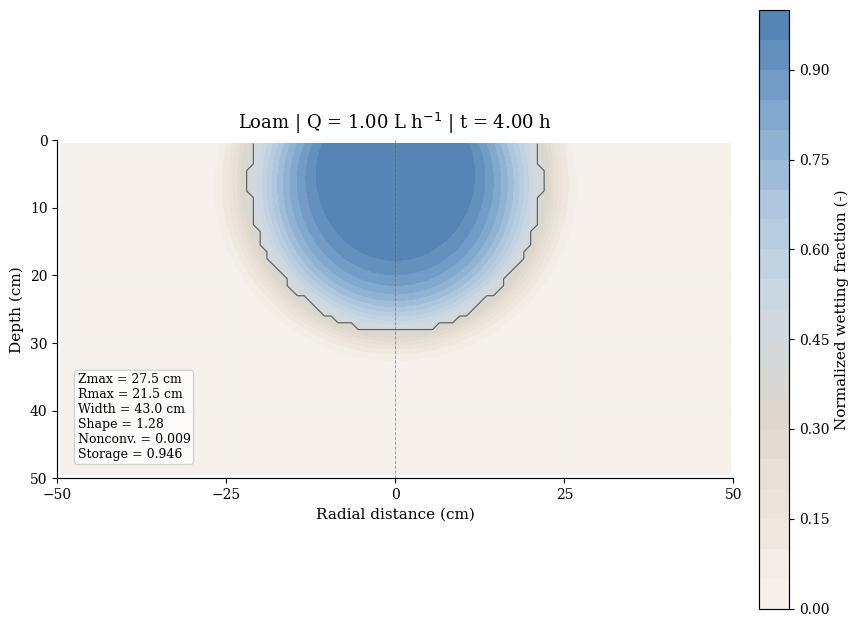

In [5]:
calc_res, calc_df = run_wetting_bulb_calculator(
    texture_name="Loam",
    Q_Lh=1.0,
    irrigation_time_h=4.0,
    fw_threshold=0.40,
    force_rerun=True,
    plot=True
)

Temporary domain defined: Rmax=50.0 cm, Zmax=50.0 cm, dr=1.00 cm, dz=1.00 cm, nr=50, nz=50, N=2500

Running verification case: grid_base_Loam_1cm
Texture: Loam
Schedule: medium_safe_track
Domain: 50.0 x 50.0 cm
Grid: dr=1.0, dz=1.0
Temporary domain defined: Rmax=50.0 cm, Zmax=50.0 cm, dr=2.00 cm, dz=2.00 cm, nr=25, nz=25, N=625

Running verification case: grid_alt_Loam_2cm
Texture: Loam
Schedule: medium_safe_track
Domain: 50.0 x 50.0 cm
Grid: dr=2.0, dz=2.0
Temporary domain defined: Rmax=50.0 cm, Zmax=50.0 cm, dr=1.00 cm, dz=1.00 cm, nr=50, nz=50, N=2500

Running verification case: domain_base_ClayLoam_50cm
Texture: Clay Loam
Schedule: fine_careful_start
Domain: 50.0 x 50.0 cm
Grid: dr=1.0, dz=1.0
Temporary domain defined: Rmax=75.0 cm, Zmax=75.0 cm, dr=1.00 cm, dz=1.00 cm, nr=75, nz=75, N=5625

Running verification case: domain_alt_ClayLoam_75cm
Texture: Clay Loam
Schedule: fine_careful_start
Domain: 75.0 x 75.0 cm
Grid: dr=1.0, dz=1.0
Temporary domain defined: Rmax=50.0 cm, Zmax=50.0

,case_label,case_id,texture,phase_run_id,schedule_name,variant_name,R_domain_cm,Z_domain_cm,dr_cm,dz_cm,...,depth_cm,radial_extent_cm,width_cm,volume_cm3,shape_ratio,nonconv_ratio,storage_ratio,rescued_steps,runtime_s,numerical_quality
0,grid_base_Loam_1cm,a650f8c67889e69c,Loam,M3_R1,medium_safe_track,medium_A,50.0,50.0,1.0,1.0,...,27.5,21.5,43.0,30561.413334,1.279070,0.008838,0.945534,0,939.789726,Moderate
1,grid_alt_Loam_2cm,8c6d492cde642940,Loam,M3_R1,medium_safe_track,medium_A,50.0,50.0,2.0,2.0,...,27.0,21.0,42.0,30435.749628,1.285714,0.000000,0.945685,0,171.197103,Moderate
2,domain_base_ClayLoam_50cm,21680fdf92baa39d,Clay Loam,C5_R1,fine_careful_start,candidate_A,50.0,50.0,1.0,1.0,...,35.5,27.5,55.0,65439.374974,1.290909,0.014058,0.976128,1,1040.340683,High
3,domain_alt_ClayLoam_75cm,3e73ef6ab73ba0be,Clay Loam,C5_R1,fine_careful_start,candidate_A,75.0,75.0,1.0,1.0,...,35.5,27.5,55.0,65439.374974,1.290909,0.014058,0.949078,1,29359.871103,Moderate
4,schedule_base_Loam,fcca1d73278e0da1,Loam,M3_R1,medium_safe_track,medium_A,50.0,50.0,1.0,1.0,...,27.5,21.5,43.0,30561.413334,1.279070,0.008838,0.945534,0,1271.289527,Moderate
5,schedule_alt_Loam,b98497c523026167,Loam,M3_R1,medium_guarded_alt,medium_A,50.0,50.0,1.0,1.0,...,27.5,21.5,43.0,30442.032813,1.279070,0.006410,0.943686,0,375.653971,Moderate
6,schedule_base_ClayLoam,8e5237c11cde29ad,Clay Loam,C5_R1,fine_careful_start,candidate_A,50.0,50.0,1.0,1.0,...,35.5,27.5,55.0,65439.374974,1.290909,0.014058,0.976128,1,468.056147,High
7,schedule_alt_ClayLoam,c1290594a727f7d2,Clay Loam,C5_R1,fine_guarded_alt,candidate_A,50.0,50.0,1.0,1.0,...,34.5,27.5,55.0,65203.755525,1.254545,0.005906,0.971761,1,742.808959,High



Verification comparison:


,test_id,texture,baseline_case,alternative_case,baseline_schedule,alternative_schedule,baseline_grid,alternative_grid,baseline_domain,alternative_domain,delta_Zmax_pct,delta_Rmax_pct,delta_width_pct,delta_volume_pct,delta_shape_pct,max_abs_geometry_delta_pct,delta_storage_ratio,delta_nonconv_ratio,runtime_ratio_alt_over_base,interpretation
0,Grid resolution check - Loam,Loam,grid_base_Loam_1cm,grid_alt_Loam_2cm,medium_safe_track,medium_safe_track,1.0 x 1.0 cm,2.0 x 2.0 cm,50.0 x 50.0 cm,50.0 x 50.0 cm,-1.818182,-2.325581,-2.325581,-0.411184,0.519481,2.325581,0.000151,-0.008838,0.182165,Stable geometry; negligible numerical-decision...
1,Domain-size check - Clay Loam,Clay Loam,domain_base_ClayLoam_50cm,domain_alt_ClayLoam_75cm,fine_careful_start,fine_careful_start,1.0 x 1.0 cm,1.0 x 1.0 cm,50.0 x 50.0 cm,75.0 x 75.0 cm,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.027050,0.000000,28.221401,Stable geometry; negligible numerical-decision...
2,Time-step schedule check - Loam,Loam,schedule_base_Loam,schedule_alt_Loam,medium_safe_track,medium_guarded_alt,1.0 x 1.0 cm,1.0 x 1.0 cm,50.0 x 50.0 cm,50.0 x 50.0 cm,0.000000,0.000000,0.000000,-0.390625,0.000000,0.390625,-0.001848,-0.002428,0.295490,Stable geometry; negligible numerical-decision...
3,Time-step schedule check - Clay Loam,Clay Loam,schedule_base_ClayLoam,schedule_alt_ClayLoam,fine_careful_start,fine_guarded_alt,1.0 x 1.0 cm,1.0 x 1.0 cm,50.0 x 50.0 cm,50.0 x 50.0 cm,-2.816901,0.000000,0.000000,-0.360058,-2.816901,2.816901,-0.004367,-0.008152,1.587008,Stable geometry; negligible numerical-decision...



Exported figure:
 - richards_axisymmetric_sensitivity_v1\numerical_verification\Figure_S5_numerical_verification_checks.png
 - richards_axisymmetric_sensitivity_v1\numerical_verification\Figure_S5_numerical_verification_checks.pdf
 - richards_axisymmetric_sensitivity_v1\numerical_verification\Figure_S5_numerical_verification_checks.svg


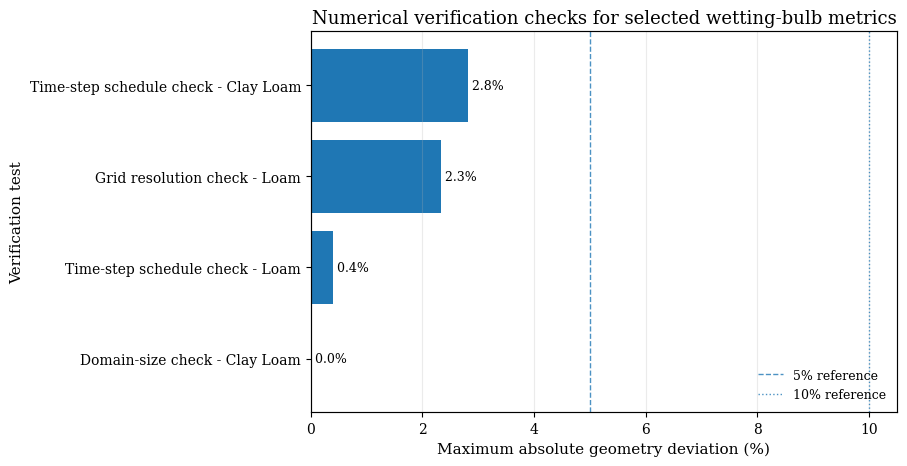


INTERPRETACIÓN SUGERIDA
Maximum absolute geometry deviation across verification checks: 2.82%
Maximum absolute storage-ratio difference across verification checks: 0.0271
Maximum absolute non-convergence-ratio difference across verification checks: 0.0088

Suggested interpretation: The verification checks indicate stable wetting-bulb geometry under the tested numerical changes.


In [6]:
# ==========================================================
# BLOCK 4: NUMERICAL VERIFICATION CHECKS
# Numerical verification checks for the associated manuscript
#
# Run after executing Blocks 0, 1, 2, and 3.
#
# Objective:
#   Verify that the main wetting-bulb geometry does not depend excessively
#   on:
#     1) spatial resolution,
#     2) domain size,
#     3) time-step schedule.
#
# Outputs:
#   - table_S5_numerical_verification_case_metrics.csv
#   - table_S5_numerical_verification_comparison.csv
#   - Figure_S5_numerical_verification_checks.png/pdf/svg
# ==========================================================

import os
import copy
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 4.0 PREVIOUS-OBJECT VALIDATION
# ----------------------------------------------------------

required_objects_for_verification = [
    "soil_params",
    "FROZEN_NUMERICAL_CONFIGS",
    "DT_SCHEDULES_PHYSICAL",
    "SCHEDULE_SENSITIVITY_BY_TEXTURE",
    "run_one_case_axisymmetric",
    "OUTDIR",
    "SAVE_DIR",
    "FIGDIR",
    "NPZ_DIR",
    "r",
    "z",
    "cell_volume"
]

missing_objects = [
    obj for obj in required_objects_for_verification
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "Before running Block 4, execute Blocks 0, 1, 2, and 3. "
        "Missing objects/functions: "
        + ", ".join(missing_objects)
    )

VERIF_DIR = os.path.join(OUTDIR, "numerical_verification")
os.makedirs(VERIF_DIR, exist_ok=True)

VERIF_CASE_METRICS_CSV = os.path.join(
    VERIF_DIR,
    "table_S5_numerical_verification_case_metrics.csv"
)

VERIF_COMPARISON_CSV = os.path.join(
    VERIF_DIR,
    "table_S5_numerical_verification_comparison.csv"
)

# ----------------------------------------------------------
# 4.1 GENERAL TEST CONFIGURATION
# ----------------------------------------------------------

# Baseline manuscript condition
BASE_Q_LH = 1.0
BASE_T_FINAL_H = 4.0
BASE_FW_THRESHOLD = 0.40
BASE_EMITTER_RADIUS_CM = 1.50

# Keep False by default. The 0.5-cm grid can be computationally expensive.
RUN_OPTIONAL_FINE_GRID = False

# Force recomputation to avoid using cached results from earlier runs.
FORCE_RERUN_VERIFICATION = True

# Set verbose to False to suppress per-step output.
VERBOSE_VERIFICATION = False

# ----------------------------------------------------------
# 4.2 TOOLS FOR TEMPORARILY CHANGING DOMAIN AND GRID
# ----------------------------------------------------------

def _capture_domain_state():
    """
    Save the current global domain and solver-geometry state.
    """
    keys = [
        "Rmax", "Zmax", "dr", "dz", "nr", "nz", "N",
        "r", "z",
        "r_inner", "r_outer",
        "rw_arr", "re_arr",
        "A_h_arr", "V_arr",
        "A_rw_arr", "A_re_arr",
        "cell_volume"
    ]

    state = {}
    for k in keys:
        if k in globals():
            state[k] = copy.deepcopy(globals()[k])

    return state


def _restore_domain_state(state):
    """
    Restore the original solver domain.
    """
    for k, v in state.items():
        globals()[k] = v


def set_axisymmetric_domain(
    Rmax_new=50.0,
    Zmax_new=50.0,
    dr_new=1.0,
    dz_new=1.0
):
    """
    Redefine the global axisymmetric domain used by the solver.

    Importante:
    El solver original usa variables globales como r, z, nr, nz,
    cell_volume and face areas. This function rebuilds them
    temporarily for each verification test.
    """

    global Rmax, Zmax, dr, dz, nr, nz, N
    global r, z
    global r_inner, r_outer
    global rw_arr, re_arr
    global A_h_arr, V_arr
    global A_rw_arr, A_re_arr
    global cell_volume

    Rmax = float(Rmax_new)
    Zmax = float(Zmax_new)
    dr = float(dr_new)
    dz = float(dz_new)

    nr = int(round(Rmax / dr))
    nz = int(round(Zmax / dz))
    N = nr * nz

    r = (np.arange(nr) + 0.5) * dr
    z = (np.arange(nz) + 0.5) * dz

    r_inner = np.maximum(r - 0.5 * dr, 0.0)
    r_outer = r + 0.5 * dr

    rw_arr = np.maximum(r - 0.5 * dr, 0.0)
    re_arr = r + 0.5 * dr

    A_h_arr = 2.0 * np.pi * r * dr
    V_arr = 2.0 * np.pi * r * dr * dz
    A_rw_arr = 2.0 * np.pi * rw_arr * dz
    A_re_arr = 2.0 * np.pi * re_arr * dz

    cell_volume = np.tile(V_arr, (nz, 1))

    print(
        f"Temporary domain defined: "
        f"Rmax={Rmax:.1f} cm, Zmax={Zmax:.1f} cm, "
        f"dr={dr:.2f} cm, dz={dz:.2f} cm, "
        f"nr={nr}, nz={nz}, N={N}"
    )


def _safe_slug(x):
    """
    Safe label for file and case names.
    """
    return (
        str(x)
        .replace(" ", "_")
        .replace(".", "p")
        .replace("-", "m")
        .replace("/", "_")
    )


# ----------------------------------------------------------
# 4.3 PHYSICAL AND NUMERICAL CONFIGURATIONS FOR VERIFICATION
# ----------------------------------------------------------

def make_verification_physical_cfg(
    Q_Lh=BASE_Q_LH,
    t_final_h=BASE_T_FINAL_H,
    emitter_radius_cm=BASE_EMITTER_RADIUS_CM,
    fw_threshold=BASE_FW_THRESHOLD
):
    """
    Common physical configuration for the verification tests.
    """
    return {
        "Q_Lh": float(Q_Lh),
        "emitter_radius_cm": float(emitter_radius_cm),
        "fw_threshold": float(fw_threshold),
        "t_final_h": float(t_final_h)
    }


def make_verification_solver_cfg(texture_name, schedule_override=None):
    """
    Copy the selected numerical configuration for a texture.
    Optionally replace the time-step schedule.
    """
    if texture_name not in FROZEN_NUMERICAL_CONFIGS:
        raise ValueError(
            f"Unrecognized texture: {texture_name}. "
            f"Opciones: {list(FROZEN_NUMERICAL_CONFIGS.keys())}"
        )

    cfg = copy.deepcopy(FROZEN_NUMERICAL_CONFIGS[texture_name])

    if schedule_override is not None:
        if schedule_override not in DT_SCHEDULES_PHYSICAL:
            raise ValueError(
                f"Schedule no reconocido: {schedule_override}. "
                f"Available options: {list(DT_SCHEDULES_PHYSICAL.keys())}"
            )
        cfg["schedule_name"] = schedule_override

    return cfg


# ----------------------------------------------------------
# 4.4 VERIFICATION-RUN EXECUTOR
# ----------------------------------------------------------

def run_verification_case(
    case_label,
    texture_name,
    R_domain_cm=50.0,
    Z_domain_cm=50.0,
    dr_cm=1.0,
    dz_cm=1.0,
    schedule_override=None,
    force_rerun=FORCE_RERUN_VERIFICATION,
    verbose=VERBOSE_VERIFICATION
):
    """
    Run a verification case using the existing solver.
    Temporarily changes the domain/grid, runs the case, and returns metrics.
    """

    set_axisymmetric_domain(
        Rmax_new=R_domain_cm,
        Zmax_new=Z_domain_cm,
        dr_new=dr_cm,
        dz_new=dz_cm
    )

    solver_cfg = make_verification_solver_cfg(
        texture_name=texture_name,
        schedule_override=schedule_override
    )

    physical_cfg = make_verification_physical_cfg()

    schedule_tag = solver_cfg["schedule_name"]

    scenario_name = (
        "verif_"
        f"{_safe_slug(case_label)}_"
        f"{_safe_slug(texture_name)}_"
        f"R{_safe_slug(R_domain_cm)}_Z{_safe_slug(Z_domain_cm)}_"
        f"dr{_safe_slug(dr_cm)}_dz{_safe_slug(dz_cm)}_"
        f"{_safe_slug(schedule_tag)}"
    )

    scenario_note = (
        "Numerical verification run. "
        "Hydraulic parameters and forcing were fixed; only grid, domain size, "
        "or time-step schedule was changed."
    )

    print("\n" + "=" * 90)
    print(f"Running verification case: {case_label}")
    print(f"Texture: {texture_name}")
    print(f"Schedule: {schedule_tag}")
    print(f"Domain: {R_domain_cm} x {Z_domain_cm} cm")
    print(f"Grid: dr={dr_cm}, dz={dz_cm}")
    print("=" * 90)

    res = run_one_case_axisymmetric(
        texture_name=texture_name,
        solver_cfg=solver_cfg,
        physical_cfg=physical_cfg,
        scenario_name=scenario_name,
        scenario_note=scenario_note,
        group_name="numerical_verification",
        snapshot_times_h=[physical_cfg["t_final_h"]],
        save_npz=True,
        force_rerun=force_rerun,
        verbose=verbose
    )

    row = {
        "case_label": case_label,
        "case_id": res.get("case_id"),
        "texture": texture_name,
        "phase_run_id": res.get("phase_run_id"),
        "schedule_name": res.get("schedule_name"),
        "variant_name": res.get("variant_name"),
        "R_domain_cm": R_domain_cm,
        "Z_domain_cm": Z_domain_cm,
        "dr_cm": dr_cm,
        "dz_cm": dz_cm,
        "nr": nr,
        "nz": nz,
        "N": N,
        "Q_Lh": physical_cfg["Q_Lh"],
        "t_final_h": physical_cfg["t_final_h"],
        "emitter_radius_cm": physical_cfg["emitter_radius_cm"],
        "fw_threshold": physical_cfg["fw_threshold"],
        "depth_cm": res.get("depth_cm", np.nan),
        "radial_extent_cm": res.get("radial_extent_cm", np.nan),
        "width_cm": res.get("width_cm", np.nan),
        "volume_cm3": res.get("volume_cm3", np.nan),
        "shape_ratio": res.get("shape_ratio", np.nan),
        "nonconv_ratio": res.get("nonconv_ratio", np.nan),
        "storage_ratio": res.get("storage_ratio", np.nan),
        "rescued_steps": res.get("rescued_steps", np.nan),
        "runtime_s": res.get("runtime_s", np.nan),
        "numerical_quality": res.get("numerical_quality", "")
    }

    return row, res


# ----------------------------------------------------------
# 4.5 BASELINE-VERSUS-ALTERNATIVE COMPARISON
# ----------------------------------------------------------

def _pct_delta(alt, base):
    """
    Cambio porcentual seguro.
    """
    if pd.isna(alt) or pd.isna(base):
        return np.nan
    if abs(base) < 1e-12:
        return np.nan
    return 100.0 * (alt - base) / abs(base)


def compare_verification_pair(test_id, base_row, alt_row):
    """
    Compare an alternative against its baseline case.
    """

    delta_depth = _pct_delta(alt_row["depth_cm"], base_row["depth_cm"])
    delta_radial = _pct_delta(alt_row["radial_extent_cm"], base_row["radial_extent_cm"])
    delta_width = _pct_delta(alt_row["width_cm"], base_row["width_cm"])
    delta_volume = _pct_delta(alt_row["volume_cm3"], base_row["volume_cm3"])
    delta_shape = _pct_delta(alt_row["shape_ratio"], base_row["shape_ratio"])

    geom_deltas = [
        delta_depth,
        delta_radial,
        delta_width,
        delta_volume,
        delta_shape
    ]

    max_abs_geom_delta = np.nanmax(np.abs(geom_deltas))

    delta_storage = alt_row["storage_ratio"] - base_row["storage_ratio"]
    delta_nonconv = alt_row["nonconv_ratio"] - base_row["nonconv_ratio"]

    runtime_ratio = (
        alt_row["runtime_s"] / base_row["runtime_s"]
        if base_row["runtime_s"] and base_row["runtime_s"] > 0
        else np.nan
    )

    if max_abs_geom_delta <= 5 and abs(delta_storage) <= 0.03:
        interpretation = "Stable geometry; negligible numerical-decision effect."
    elif max_abs_geom_delta <= 10 and abs(delta_storage) <= 0.05:
        interpretation = "Moderate but acceptable deviation; directional interpretation preserved."
    else:
        interpretation = "Sensitive response; report as limitation or inspect field visually."

    return {
        "test_id": test_id,
        "texture": base_row["texture"],
        "baseline_case": base_row["case_label"],
        "alternative_case": alt_row["case_label"],
        "baseline_schedule": base_row["schedule_name"],
        "alternative_schedule": alt_row["schedule_name"],
        "baseline_grid": f"{base_row['dr_cm']} x {base_row['dz_cm']} cm",
        "alternative_grid": f"{alt_row['dr_cm']} x {alt_row['dz_cm']} cm",
        "baseline_domain": f"{base_row['R_domain_cm']} x {base_row['Z_domain_cm']} cm",
        "alternative_domain": f"{alt_row['R_domain_cm']} x {alt_row['Z_domain_cm']} cm",
        "delta_Zmax_pct": delta_depth,
        "delta_Rmax_pct": delta_radial,
        "delta_width_pct": delta_width,
        "delta_volume_pct": delta_volume,
        "delta_shape_pct": delta_shape,
        "max_abs_geometry_delta_pct": max_abs_geom_delta,
        "delta_storage_ratio": delta_storage,
        "delta_nonconv_ratio": delta_nonconv,
        "runtime_ratio_alt_over_base": runtime_ratio,
        "interpretation": interpretation
    }


# ----------------------------------------------------------
# 4.6 TEST DEFINITIONS
# ----------------------------------------------------------

def get_alt_schedule(texture_name):
    """
    Retrieve the alternative schedule for the texture.
    Usa SCHEDULE_SENSITIVITY_BY_TEXTURE si existe.
    """
    if texture_name not in SCHEDULE_SENSITIVITY_BY_TEXTURE:
        return None

    schedules = SCHEDULE_SENSITIVITY_BY_TEXTURE[texture_name]

    if len(schedules) < 2:
        return None

    return schedules[1]


verification_pairs = [
    {
        "test_id": "Grid resolution check - Loam",
        "base": {
            "case_label": "grid_base_Loam_1cm",
            "texture_name": "Loam",
            "R_domain_cm": 50.0,
            "Z_domain_cm": 50.0,
            "dr_cm": 1.0,
            "dz_cm": 1.0,
            "schedule_override": None,
        },
        "alternative": {
            "case_label": "grid_alt_Loam_2cm",
            "texture_name": "Loam",
            "R_domain_cm": 50.0,
            "Z_domain_cm": 50.0,
            "dr_cm": 2.0,
            "dz_cm": 2.0,
            "schedule_override": None,
        },
    },
    {
        "test_id": "Domain-size check - Clay Loam",
        "base": {
            "case_label": "domain_base_ClayLoam_50cm",
            "texture_name": "Clay Loam",
            "R_domain_cm": 50.0,
            "Z_domain_cm": 50.0,
            "dr_cm": 1.0,
            "dz_cm": 1.0,
            "schedule_override": None,
        },
        "alternative": {
            "case_label": "domain_alt_ClayLoam_75cm",
            "texture_name": "Clay Loam",
            "R_domain_cm": 75.0,
            "Z_domain_cm": 75.0,
            "dr_cm": 1.0,
            "dz_cm": 1.0,
            "schedule_override": None,
        },
    },
    {
        "test_id": "Time-step schedule check - Loam",
        "base": {
            "case_label": "schedule_base_Loam",
            "texture_name": "Loam",
            "R_domain_cm": 50.0,
            "Z_domain_cm": 50.0,
            "dr_cm": 1.0,
            "dz_cm": 1.0,
            "schedule_override": None,
        },
        "alternative": {
            "case_label": "schedule_alt_Loam",
            "texture_name": "Loam",
            "R_domain_cm": 50.0,
            "Z_domain_cm": 50.0,
            "dr_cm": 1.0,
            "dz_cm": 1.0,
            "schedule_override": get_alt_schedule("Loam"),
        },
    },
    {
        "test_id": "Time-step schedule check - Clay Loam",
        "base": {
            "case_label": "schedule_base_ClayLoam",
            "texture_name": "Clay Loam",
            "R_domain_cm": 50.0,
            "Z_domain_cm": 50.0,
            "dr_cm": 1.0,
            "dz_cm": 1.0,
            "schedule_override": None,
        },
        "alternative": {
            "case_label": "schedule_alt_ClayLoam",
            "texture_name": "Clay Loam",
            "R_domain_cm": 50.0,
            "Z_domain_cm": 50.0,
            "dr_cm": 1.0,
            "dz_cm": 1.0,
            "schedule_override": get_alt_schedule("Clay Loam"),
        },
    },
]

if RUN_OPTIONAL_FINE_GRID:
    verification_pairs.append(
        {
            "test_id": "Fine-grid optional check - Loam",
            "base": {
                "case_label": "fine_grid_base_Loam_1cm",
                "texture_name": "Loam",
                "R_domain_cm": 50.0,
                "Z_domain_cm": 50.0,
                "dr_cm": 1.0,
                "dz_cm": 1.0,
                "schedule_override": None,
            },
            "alternative": {
                "case_label": "fine_grid_alt_Loam_0p5cm",
                "texture_name": "Loam",
                "R_domain_cm": 50.0,
                "Z_domain_cm": 50.0,
                "dr_cm": 0.5,
                "dz_cm": 0.5,
                "schedule_override": None,
            },
        }
    )


# ----------------------------------------------------------
# 4.7 EXECUTION OF ALL VERIFICATION TESTS
# ----------------------------------------------------------

original_domain_state = _capture_domain_state()

case_rows = {}
comparison_rows = []

try:
    for pair in verification_pairs:

        base_spec = pair["base"]
        alt_spec = pair["alternative"]

        # Skip if no alternative schedule exists
        if alt_spec.get("schedule_override") is None and "schedule" in pair["test_id"].lower():
            print(f"Skipping {pair['test_id']}: no alternative schedule is defined.")
            continue

        # Run baseline if it does not already exist
        base_label = base_spec["case_label"]
        if base_label not in case_rows:
            base_row, _ = run_verification_case(**base_spec)
            case_rows[base_label] = base_row

        # Run alternative if it does not already exist
        alt_label = alt_spec["case_label"]
        if alt_label not in case_rows:
            alt_row, _ = run_verification_case(**alt_spec)
            case_rows[alt_label] = alt_row

        # Compare
        comp = compare_verification_pair(
            test_id=pair["test_id"],
            base_row=case_rows[base_label],
            alt_row=case_rows[alt_label]
        )

        comparison_rows.append(comp)

finally:
    # Important: restore the original notebook domain
    _restore_domain_state(original_domain_state)
    print("\nOriginal domain restored.")


verification_case_metrics_df = pd.DataFrame(list(case_rows.values()))
verification_comparison_df = pd.DataFrame(comparison_rows)

verification_case_metrics_df.to_csv(VERIF_CASE_METRICS_CSV, index=False)
verification_comparison_df.to_csv(VERIF_COMPARISON_CSV, index=False)

print("\nArchivos exportados:")
print(" -", VERIF_CASE_METRICS_CSV)
print(" -", VERIF_COMPARISON_CSV)

print("\nSummary of executed cases:")
display(verification_case_metrics_df)

print("\nVerification comparison:")
display(verification_comparison_df)


# ----------------------------------------------------------
# 4.8 VERIFICATION-SUMMARY FIGURE
# ----------------------------------------------------------

if not verification_comparison_df.empty:

    fig, ax = plt.subplots(figsize=(9.2, 4.8))

    plot_df = verification_comparison_df.copy()
    plot_df = plot_df.sort_values("max_abs_geometry_delta_pct", ascending=True)

    ax.barh(
        plot_df["test_id"],
        plot_df["max_abs_geometry_delta_pct"]
    )

    ax.axvline(
        5,
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        label="5% reference"
    )

    ax.axvline(
        10,
        linestyle=":",
        linewidth=1.0,
        alpha=0.8,
        label="10% reference"
    )

    ax.set_xlabel("Maximum absolute geometry deviation (%)")
    ax.set_ylabel("Verification test")
    ax.set_title("Numerical verification checks for selected wetting-bulb metrics")

    ax.grid(True, axis="x", alpha=0.25)
    ax.legend(frameon=False, loc="lower right")

    for i, val in enumerate(plot_df["max_abs_geometry_delta_pct"]):
        if np.isfinite(val):
            ax.text(
                val,
                i,
                f" {val:.1f}%",
                va="center",
                fontsize=9
            )

    fig.tight_layout()

    fig_base = os.path.join(
        VERIF_DIR,
        "Figure_S5_numerical_verification_checks"
    )

    fig.savefig(fig_base + ".png", dpi=600, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_base + ".pdf", bbox_inches="tight", facecolor="white")
    fig.savefig(fig_base + ".svg", bbox_inches="tight", facecolor="white")

    print("\nExported figure:")
    print(" -", fig_base + ".png")
    print(" -", fig_base + ".pdf")
    print(" -", fig_base + ".svg")

    plt.show()


# ----------------------------------------------------------
# 4.9 Texto automático para interpretar el resultado
# ----------------------------------------------------------

if not verification_comparison_df.empty:

    max_dev = verification_comparison_df["max_abs_geometry_delta_pct"].max()
    max_storage_delta = verification_comparison_df["delta_storage_ratio"].abs().max()
    max_nonconv_delta = verification_comparison_df["delta_nonconv_ratio"].abs().max()

    print("\n" + "=" * 90)
    print("INTERPRETACIÓN SUGERIDA")
    print("=" * 90)

    print(
        f"Maximum absolute geometry deviation across verification checks: "
        f"{max_dev:.2f}%"
    )

    print(
        f"Maximum absolute storage-ratio difference across verification checks: "
        f"{max_storage_delta:.4f}"
    )

    print(
        f"Maximum absolute non-convergence-ratio difference across verification checks: "
        f"{max_nonconv_delta:.4f}"
    )

    if max_dev <= 5 and max_storage_delta <= 0.03:
        print(
            "\nSuggested interpretation: The verification checks indicate stable "
            "wetting-bulb geometry under the tested numerical changes."
        )
    elif max_dev <= 10 and max_storage_delta <= 0.05:
        print(
            "\nSuggested interpretation: The verification checks indicate moderate "
            "numerical sensitivity, but the directional interpretation of wetting-bulb "
            "geometry is preserved."
        )
    else:
        print(
            "\nSuggested interpretation: At least one verification check produced "
            "substantial sensitivity. Inspect the corresponding wetting field and "
            "report this as a limitation or numerical-decision sensitivity."
        )